### словари

In [ ]:
import re
import pandas as pd
from collections import Counter
import os
import spacy
import nltk
from nltk.corpus import wordnet as wn
from wordfreq import zipf_frequency
import contractions
import matplotlib.pyplot as plt
import fasttext

In [49]:
df = pd.read_csv('london_posts_2020.csv', nrows=500000)

In [50]:
df.head()

,id,shortcode,imageurl,isvideo,caption,commentscount,timestamp,likescount,isad,authorid,locationid,lat,lon
0,2222074995257723453,B7WZW9knUo9,https://scontent-amt2-1.cdninstagram.com/v/t51...,f,Our saddlers have been making these beautiful ...,5,1579112003,56,f,2323850475,106117686260824,51.400000,0.066667
1,2221936748253256770,B7V57NBBZxC,https://scontent-lga3-1.cdninstagram.com/v/t51...,f,Limited tickets remaining for Friday 7pm perfo...,0,1579095522,34,f,5576777004,1530294183865128,51.415549,0.069330
2,2221820195022622494,B7VfbIXHM8e,https://instagram.fprg2-1.fna.fbcdn.net/v/t51....,f,Fresh juices are now available at @bankhousebr...,2,1579081631,54,f,12559601976,328666287815372,51.416950,0.068510
3,2222034209566973726,B7WQFc8AV8e,https://instagram.fprg2-1.fna.fbcdn.net/v/t51....,f,New nasheed ‘Duniya Ke Ae Musafir’ releasing t...,20,1579107141,703,f,212277138,349469628,51.428392,0.081491
4,2221944454187921855,B7V7rVuhTG_,https://scontent-arn2-1.cdninstagram.com/v/t51...,f,Fresh on cask today!\n@cloudwaterbrew •\n#beer...,0,1579096441,13,f,5895023530,1989160247985606,51.441360,0.086775


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             500000 non-null  int64  
 1   shortcode      500000 non-null  object 
 2   imageurl       500000 non-null  object 
 3   isvideo        500000 non-null  object 
 4   caption        463262 non-null  object 
 5   commentscount  500000 non-null  int64  
 6   timestamp      500000 non-null  int64  
 7   likescount     500000 non-null  int64  
 8   isad           500000 non-null  object 
 9   authorid       500000 non-null  int64  
 10  locationid     500000 non-null  int64  
 11  lat            500000 non-null  float64
 12  lon            500000 non-null  float64
dtypes: float64(2), int64(6), object(5)
memory usage: 49.6+ MB


In [52]:
df = df[df["caption"].notna()]

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 463262 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             463262 non-null  int64  
 1   shortcode      463262 non-null  object 
 2   imageurl       463262 non-null  object 
 3   isvideo        463262 non-null  object 
 4   caption        463262 non-null  object 
 5   commentscount  463262 non-null  int64  
 6   timestamp      463262 non-null  int64  
 7   likescount     463262 non-null  int64  
 8   isad           463262 non-null  object 
 9   authorid       463262 non-null  int64  
 10  locationid     463262 non-null  int64  
 11  lat            463262 non-null  float64
 12  lon            463262 non-null  float64
dtypes: float64(2), int64(6), object(5)
memory usage: 49.5+ MB


детекция языка через fasttext, оставляем только английский

label → предсказанный язык

prob  → вероятность (confidence)

In [ ]:
ft_model  = fasttext.load_model("lid.176.bin")

def detect_lang(text, threshold=0.8):
    if not text or len(text) < 3:
        return False

    label, prob = ft_model.predict(text.replace("\n", " "), k=1)

    lang = label[0].replace("__label__", "")
    conf = prob[0]

    return lang == "en" and conf >= threshold

TEXT_COL = "caption"

df["is_en"] = df[TEXT_COL].apply(detect_lang)
df = df[df["is_en"]]

**эксперименты с фильтрацией:**

загружаем 55000
количество строк до (непустые): 50 716

1. threshold = 0.7, остается 19 807
2. threshold = 0.75, остается 17 234
3. threshold = 0.8, остается 14 431
4. threshold = 0.85, остается 11 153
5. threshold = 0.9, остается 7 536

загружаем 200 000
количество строк до (непустые): 184 217

1. threshold = 0.7, остается 72 243
2. threshold = 0.75, остается 62 764
3. threshold = 0.8, остается 52 682
4. threshold = 0.85, остается 41 073
5. threshold = 0.9, остается 27 810

загружаем 500 000
количество строк до (непустые): 463 262

1. threshold = 0.7, остается 183 760
2. threshold = 0.75, остается 160 681
3. threshold = 0.8, остается 135 357 - берем 
4. threshold = 0.85, остается 106 628
5. threshold = 0.9, остается 73 159 

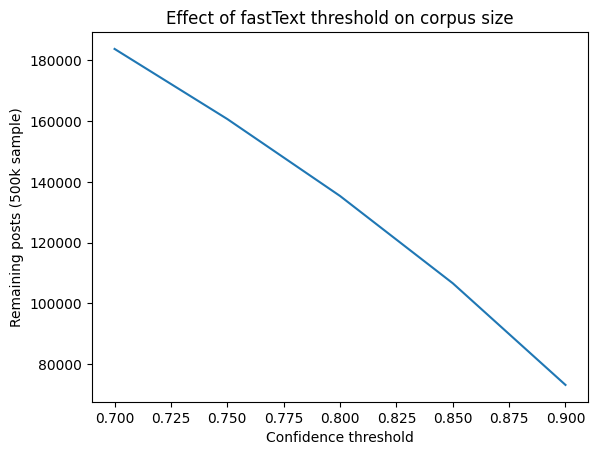

In [ ]:
filter_stats = pd.DataFrame({
    "threshold": [0.7, 0.75, 0.8, 0.85, 0.9],
    "posts_55k": [19807, 17234, 14431, 11153, 7536],
    "posts_200k": [72243, 62764, 52682, 41073, 27810],
    "posts_500k": [183760, 160681, 135357, 106628, 73159]
})



plt.plot(filter_stats["threshold"], filter_stats["posts_500k"])
plt.xlabel("Confidence threshold")
plt.ylabel("Remaining posts (500k sample)")
plt.title("Effect of fastText threshold on corpus size")
plt.show()

In [56]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.strip()
    if len(text) < 3:
        return ""

    try:
        text = contractions.fix(text)
    except Exception:
        return ""

    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df[TEXT_COL].apply(clean_text)

In [57]:
len(df)

135357

фильтрация по количеству токенов, чтобы обойтись без обрезки

In [58]:
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def bert_len(text):
    if not text:
        return 0
    return len(bert_tokenizer(text, add_special_tokens=True)["input_ids"])

MAX_LEN = 505  # запас

df["bert_len"] = df["clean_text"].apply(bert_len)
df = df[df["bert_len"] <= MAX_LEN]

c:\Users\Таня\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [59]:
len(df)

135357

In [60]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def tokenize(text):
    doc = nlp(text)
    tokens = []
    for token in doc:
        if not token.is_alpha:
            continue
        if token.is_stop:
            continue
        if len(token) < 3:
            continue
        if token.ent_type_:
            continue
        tokens.append(token)
    return tokens

df["tokens"] = df["clean_text"].apply(tokenize)
df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,our saddlers have been making these beautiful ...,"[saddlers, making, beautiful, camera, cases, w..."
1,limited tickets remaining for friday pm perfor...,"[limited, tickets, remaining, friday, performa..."
5,fresh on today,"[fresh, today]"
9,she is very capricciosa but i love her this pi...,"[capricciosa, love, pizza, actually, prosciutt..."
12,cartwheels are one of those skills that can be...,"[cartwheels, skills, picked, quickly, long, ti..."


In [61]:
len(df)

135357

In [62]:
counter = Counter()
for toks in df["tokens"]:
    counter.update([t.text for t in toks])

counter.most_common(30)

[('time', 19214),
 ('day', 15891),
 ('like', 15054),
 ('london', 14590),
 ('new', 13219),
 ('love', 12196),
 ('today', 12030),
 ('good', 11504),
 ('week', 10770),
 ('people', 10296),
 ('know', 9066),
 ('work', 8928),
 ('life', 8837),
 ('home', 8713),
 ('great', 7942),
 ('year', 7806),
 ('going', 7390),
 ('best', 7282),
 ('little', 7054),
 ('want', 6956),
 ('way', 6934),
 ('happy', 6673),
 ('got', 6269),
 ('need', 6050),
 ('thank', 5924),
 ('look', 5890),
 ('amazing', 5840),
 ('come', 5764),
 ('feel', 5715),
 ('things', 5695)]

In [63]:
nltk.download("wordnet")

def in_wordnet(lemma: str) -> bool:
    return bool(wn.synsets(lemma))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Таня\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [64]:
def zipf(word: str, lang="en") -> float:
    return zipf_frequency(word, lang)

def looks_english(word: str) -> bool:
    return zipf(word, "en") >= max(
        zipf(word, "es"),
        zipf(word, "fr"),
        zipf(word, "pt"),
        zipf(word, "it")
    )

In [65]:
def slang_wordnet(word, lemma):
    return not in_wordnet(lemma)


def slang_wordnet_freq(word, lemma, min_zipf=3.0):
    return (not in_wordnet(lemma)) and zipf(word) >= min_zipf


def slang_freq_band(word, low=2.5, high=4):
    z = zipf(word)
    return low <= z <= high


# def is_proper_name(word):
    # doc = nlp(word)
    # return doc[0].pos_ == "PROPN"

In [66]:
results = {
    "wordnet_oov": set(),
    "wordnet_oov_freq": set(),
    "freq_band": set(),
}

for word, freq in counter.items():
    if freq < 5:
        continue

    if not looks_english(word):
        continue

    doc = nlp(word)
    lemma = doc[0].lemma_

    #if doc[0].pos_ == "PROPN":
        #continue
    

    if slang_wordnet(word, lemma):
        results["wordnet_oov"].add(word)

    if slang_wordnet_freq(word, lemma):
        results["wordnet_oov_freq"].add(word)

    if slang_freq_band(word):
        results["freq_band"].add(word)



In [67]:
for k, v in results.items():
    print(f"{k}: {len(v)}")

wordnet_oov: 3401
wordnet_oov_freq: 1198
freq_band: 14184


In [68]:
for k, v in results.items():
    print("\n", k)
    print(sorted(list(v))[:20])


 wordnet_oov
['aaaaand', 'aaaand', 'aaand', 'abba', 'abbas', 'abbeyroad', 'abbie', 'abbott', 'abby', 'abdul', 'abe', 'abi', 'abigail', 'abingdon', 'abit', 'ableton', 'abloh', 'abney', 'abu', 'abv']

 wordnet_oov_freq
['abba', 'abbas', 'abbott', 'abby', 'abdul', 'abe', 'abi', 'abigail', 'abu', 'achilles', 'acl', 'admin', 'aero', 'afc', 'aforementioned', 'agnes', 'aha', 'ahh', 'ahmad', 'aidan']

 freq_band
['aaa', 'aback', 'abandoning', 'abandonment', 'abba', 'abbas', 'abbey', 'abbie', 'abbot', 'abbott', 'abby', 'abdominal', 'abducted', 'abduction', 'abductions', 'abdul', 'abe', 'aberdeen', 'abi', 'abide']


In [69]:
best_candidates = (
    results["wordnet_oov"]
    & results["wordnet_oov_freq"]
    & results["freq_band"]
)

sorted(best_candidates)

['abba',
 'abbas',
 'abbott',
 'abby',
 'abdul',
 'abe',
 'abi',
 'abigail',
 'achilles',
 'acl',
 'admin',
 'aero',
 'afc',
 'aforementioned',
 'agnes',
 'aha',
 'ahh',
 'ahmad',
 'aidan',
 'aiden',
 'aisha',
 'albeit',
 'alec',
 'alexa',
 'alfie',
 'alfred',
 'alison',
 'alistair',
 'allan',
 'allison',
 'alot',
 'amid',
 'amidst',
 'andre',
 'annette',
 'antibodies',
 'anya',
 'approx',
 'archie',
 'aston',
 'aswell',
 'atkins',
 'atl',
 'atleast',
 'aubrey',
 'aud',
 'audiobook',
 'avalon',
 'avery',
 'aww',
 'awww',
 'aye',
 'babysitting',
 'backstory',
 'badass',
 'baden',
 'bae',
 'bafta',
 'bao',
 'barbour',
 'barlow',
 'barnes',
 'barnett',
 'barney',
 'barnsley',
 'barrett',
 'barton',
 'bassett',
 'baxter',
 'bbq',
 'bbw',
 'beale',
 'beatles',
 'beckham',
 'becky',
 'bedford',
 'belated',
 'belinda',
 'bellevue',
 'benji',
 'benson',
 'bentley',
 'benz',
 'bernie',
 'bert',
 'bertie',
 'bestselling',
 'bethany',
 'betsy',
 'betty',
 'beverly',
 'beyonce',
 'biceps',
 'biebe

In [70]:
pipeline_stats = pd.DataFrame({
    "stage": [
        "original_nonempty",
        "after_lang_filter",
        "unique_tokens",
        "wordnet_oov",
        "wordnet_oov_freq",
        "freq_band",
        "best_candidates"
    ],
    "count": [
        463262,  # до фильтра
        135357,  # после 0.8
        len(counter),
        len(results["wordnet_oov"]),
        len(results["wordnet_oov_freq"]),
        len(results["freq_band"]),
        len(best_candidates)
    ]
})

In [71]:
pipeline_stats

,stage,count
0,original_nonempty,463262
1,after_lang_filter,135357
2,unique_tokens,83644
3,wordnet_oov,3401
4,wordnet_oov_freq,1198
5,freq_band,14184
6,best_candidates,1046


### сохранение для каждого слова

In [76]:
def collect_contexts(word, df, min_count=20):
    contexts = []

    for text, toks in zip(df["clean_text"], df["tokens"]):
        if any(t.text == word for t in toks):
            if len(text.split()) < 5:
                continue
            contexts.append(text)

    contexts = list(dict.fromkeys(contexts))

    if len(contexts) < min_count:
        return None

    return contexts

summary_rows = []
candidate_words = sorted(best_candidates)

for word in candidate_words:
    contexts = collect_contexts(word, df)

    if not contexts:
        summary_rows.append({
            "word": word,
            "contexts_count": 0,
            "saved": False
        })
        continue

    summary_rows.append({
        "word": word,
        "contexts_count": len(contexts),
        "saved": True
    })

    df_anno = pd.DataFrame({
        "id": range(len(contexts)),
        "word": word,
        "context": contexts,
        "gold_sense": ""
    })

    df_anno.to_csv(f"annotations/{word}_annotation.csv", index=False)

df_summary = pd.DataFrame(summary_rows)

In [77]:
df_summary[df_summary['contexts_count'] != 0].to_csv("contexts_summary.csv", index=False)

In [78]:
df_summary[df_summary['contexts_count'] != 0].sort_values("contexts_count", ascending=False)

,word,contexts_count,saved
926,thames,418,True
533,kensington,287,True
586,lil,269,True
999,wellbeing,266,True
130,buckingham,240,True
...,...,...,...
666,monty,20,True
487,janet,20,True
692,nikon,20,True
16,ahh,20,True


In [79]:
df_summary[df_summary['contexts_count'] != 0].describe()

,contexts_count
count,254.000000
mean,52.862205
std,51.923712
min,20.000000
25%,25.000000
50%,34.000000
75%,56.500000
max,418.000000


### для fam

In [ ]:
df_anno

,id,word,context,gold_sense
0,0,fam,happy th to the og bro it is been a minute yea...,friends
1,1,fam,next week with my fam at introducing for his f...,family
2,2,fam,sou dragon club pelo mundo fazendo a maior fam...,other
3,3,fam,another fab night with the fam years in and st...,friends
4,4,fam,spellbinding day out with the fam,family
5,5,fam,o quarto dos nossos g meos preferidos maria e ...,other
6,6,fam,gin night fam trip for one of my agents,community
7,7,fam,thank you friends fam for all the happy birthd...,friends
8,8,fam,timidez quem nunca sua performance comunicativ...,other
9,9,fam,chegou o melhor dia da semana vamos celebrar a...,other


In [3]:
df_anno = pd.read_csv("fam_annotation.csv")

print(df_anno["gold_sense"].value_counts())

texts = df_anno["context"].tolist()
labels_gold = df_anno["gold_sense"].tolist()
term = df_anno["word"].iloc[0]

gold_sense
social      52
bio         31
vocative    23
Name: count, dtype: int64


In [23]:
from transformers import AutoTokenizer, AutoModel
import torch
from typing import List
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def prepare_dataframe(texts: List[str], term: str) -> pd.DataFrame:
    rows = []
    for t in texts:
        if re.search(rf"\b{term}\b", t, re.IGNORECASE):
            masked = re.sub(rf"\b{term}\b", "[MASK]", t, flags=re.IGNORECASE)
            rows.append({
                "text": t,
                "anon_text": masked
            })
    return pd.DataFrame(rows)

def embed_masked(texts, tokenizer, model, device):
    model.to(device)
    model.eval()
    vectors = []

    for t in texts:
        inputs = tokenizer(
            t,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            padding="max_length"
        ).to(device)

        mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)

        with torch.no_grad():
            outputs = model(**inputs)

        if len(mask_idx[1]) == 0:
            vec = torch.zeros(model.config.hidden_size).numpy()
        else:
            vec = outputs.last_hidden_state[0, mask_idx[1], :].mean(dim=0).cpu().numpy()

        vectors.append(vec)

    return np.vstack(vectors)

masked_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
masked_model = AutoModel.from_pretrained("bert-base-uncased")
device = "cuda" if torch.cuda.is_available() else "cpu"

df_term = prepare_dataframe(texts, term)
anon_texts = df_term['anon_text'].tolist()

X = embed_masked(anon_texts, masked_tokenizer, masked_model, device)

c:\Users\Таня\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [24]:
def find_best_k(X, k_min=1, k_max=5):
    best_k = k_min
    best_score = -1
    scores = {}

    max_k = min(k_max, len(X) - 1)

    for k in range(k_min, max_k + 1):
        if k == 1:
            score = 0.0
        else:
            labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
            score = silhouette_score(X, labels)

        scores[k] = score

        if score > best_score:
            best_score = score
            best_k = k

    if best_score < 0.1:
        best_k = 1
        best_score = 0.0

    return best_k, best_score, scores

def cluster_embeddings(X, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else 0
    return labels, sil, kmeans.cluster_centers_


best_k, best_score, sil_scores = find_best_k(X, k_min=1, k_max=5)
labels_pred, sil, centroids = cluster_embeddings(X, best_k)
df_anno["pred_k2"] = labels_pred

print(f"best_k = {best_k}, silhouette = {sil:.3f}")

best_k = 1, silhouette = 0.000


In [25]:
from itertools import combinations
from sklearn.metrics import precision_score, recall_score, f1_score

pairs = []
for (i1, i2) in combinations(range(len(labels_pred)), 2):
    gold_same = int(labels_gold[i1] == labels_gold[i2])
    pred_same = int(labels_pred[i1] == labels_pred[i2])
    pairs.append({
        "id1": i1,
        "id2": i2,
        "gold_same": gold_same,
        "pred_same": pred_same
    })

df_pairs = pd.DataFrame(pairs)

y_true = df_pairs["gold_same"]
y_pred = df_pairs["pred_same"]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Pairwise metrics:\nPrecision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

Pairwise metrics:
Precision: 0.519, Recall: 1.000, F1: 0.684


In [26]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

ari = adjusted_rand_score(labels_gold, labels_pred)
nmi = normalized_mutual_info_score(labels_gold, labels_pred)

print(f"ARI: {ari:.3f}")
print(f"NMI: {nmi:.3f}")

ARI: 0.000
NMI: 0.000


In [27]:
import pandas as pd

def purity_score(y_true, y_pred):
    df = pd.DataFrame({"true": y_true, "pred": y_pred})
    total = 0

    for cluster in df["pred"].unique():
        subset = df[df["pred"] == cluster]
        most_common = subset["true"].value_counts().max()
        total += most_common

    return total / len(df)

purity = purity_score(labels_gold, labels_pred)
print(f"Purity: {purity:.3f}")

Purity: 0.618


In [28]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(labels_gold, labels_pred)
nmi = normalized_mutual_info_score(labels_gold, labels_pred)
purity = purity_score(labels_gold, labels_pred)

results = {
    "Best_k": best_k,
    "Silhouette": sil,
    "Pairwise_Precision": precision,
    "Pairwise_Recall": recall,
    "Pairwise_F1": f1,
    "ARI": ari,
    "NMI": nmi,
    "Purity": purity
}

print("\n=== METRICS SUMMARY ===")
for k, v in results.items():
    if isinstance(v, float):
        print(f"{k}: {v:.3f}")
    else:
        print(f"{k}: {v}")


=== METRICS SUMMARY ===
Best_k: 1
Silhouette: 0
Pairwise_Precision: 0.519
Pairwise_Recall: 1.000
Pairwise_F1: 0.684
ARI: 0.000
NMI: 0.000
Purity: 0.618


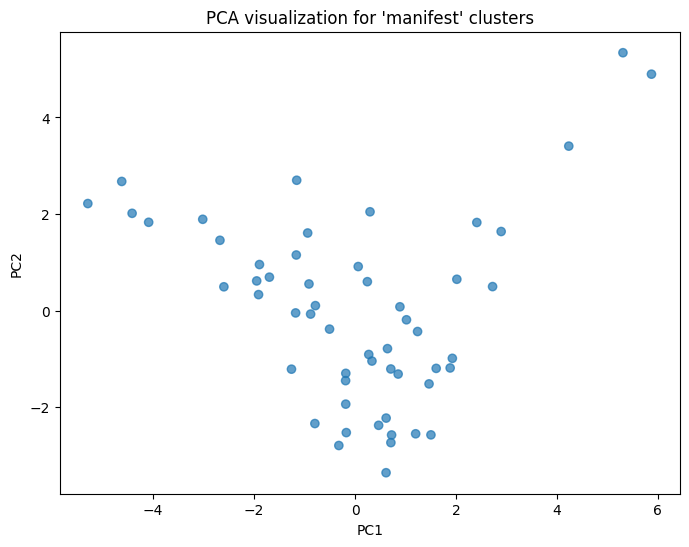

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pred, cmap="tab10", alpha=0.7)
plt.title(f"PCA visualization for '{term}' clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
def compute_metrics(labels_gold, labels_pred, X, term, k, setting):
    
    pairs = []
    for (i1, i2) in combinations(range(len(labels_pred)), 2):
        gold_same = int(labels_gold[i1] == labels_gold[i2])
        pred_same = int(labels_pred[i1] == labels_pred[i2])
        pairs.append((gold_same, pred_same))

    df_pairs = pd.DataFrame(pairs, columns=["gold_same", "pred_same"])

    precision = precision_score(df_pairs["gold_same"], df_pairs["pred_same"])
    recall = recall_score(df_pairs["gold_same"], df_pairs["pred_same"])
    f1 = f1_score(df_pairs["gold_same"], df_pairs["pred_same"])

    ari = adjusted_rand_score(labels_gold, labels_pred)
    nmi = normalized_mutual_info_score(labels_gold, labels_pred)
    purity = purity_score(labels_gold, labels_pred)

    sil = silhouette_score(X, labels_pred) if len(np.unique(labels_pred)) > 1 else 0

    return {
        "term": term,
        "setting": setting,
        "k": k,
        "silhouette": sil,
        "pairwise_precision": precision,
        "pairwise_recall": recall,
        "pairwise_f1": f1,
        "ARI": ari,
        "NMI": nmi,
        "purity": purity
    }

In [31]:
metrics_k2 = compute_metrics(
    labels_gold,
    labels_pred,
    X,
    term=term,
    k=best_k,
    setting="auto_k"
)

In [32]:
labels_pred_k3, sil_k3, _ = cluster_embeddings(X, 2)

metrics_k3 = compute_metrics(
    labels_gold,
    labels_pred_k3,
    X,
    term=term,
    k=2,
    setting="forced_k"
)

df_anno["pred_k3"] = labels_pred_k3

In [33]:
results_table = pd.DataFrame([metrics_k2, metrics_k3])

In [17]:
results_table.round(3)

,setting,k,silhouette,pairwise_precision,pairwise_recall,pairwise_f1,ARI,NMI,purity
0,auto_k,2,0.177,0.372,0.655,0.474,0.011,0.004,0.491
1,forced_k,3,0.126,0.378,0.638,0.475,0.025,0.068,0.519


In [18]:
results_table.round(3)

,term,setting,k,silhouette,pairwise_precision,pairwise_recall,pairwise_f1,ARI,NMI,purity
0,manifest,auto_k,1,0.000,0.424,1.000,0.595,0.000,0.000,0.582
1,manifest,forced_k,3,0.071,0.463,0.528,0.493,0.077,0.243,0.636


In [34]:
results_table.round(3)

,term,setting,k,silhouette,pairwise_precision,pairwise_recall,pairwise_f1,ARI,NMI,purity
0,manifest,auto_k,1,0.000,0.519,1.000,0.684,0.000,0.000,0.618
1,manifest,forced_k,2,0.056,0.545,0.555,0.550,0.055,0.107,0.636


In [17]:
df_eval = pd.DataFrame({
    "gold": labels_gold,
    "pred": labels_pred
})

pd.crosstab(df_eval["gold"], df_eval["pred"])

pred,0,1,2
gold,,,
bio,6,23,2
social,7,42,3
vocative,0,17,6


In [ ]:
correct = df_anno[df_anno["gold_sense"] == df_anno["pred_cluster"]]
wrong = df_anno[df_anno["gold_sense"] != df_anno["pred_cluster"]]

### manifest